In [1]:
from DroneEnv import DroneLandingEnv
from PIDCon import PIDController
from PID_run import run_pid_simulation

error [-2. -2. -2. -2.]
theta 2.0
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.92933238 -1.92933238 -1.99651027 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.85866477 -1.85866477 -1.99302051 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.78799716 -1.78799716 -1.98953075 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.71732955 -1.71732955 -1.98604099 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.64666195 -1.64666194 -1.98255123 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.57599434 -1.57599433 -1.97906147 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.50532673 -1.50532672 -1.97557172 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.43465913 -1.43465912 -1.97208196 -2.        ]
action [-1.9972599  5.3680491 -0.2        0.       ]
error [-1.36399152 -1.36399151 -1.9685922

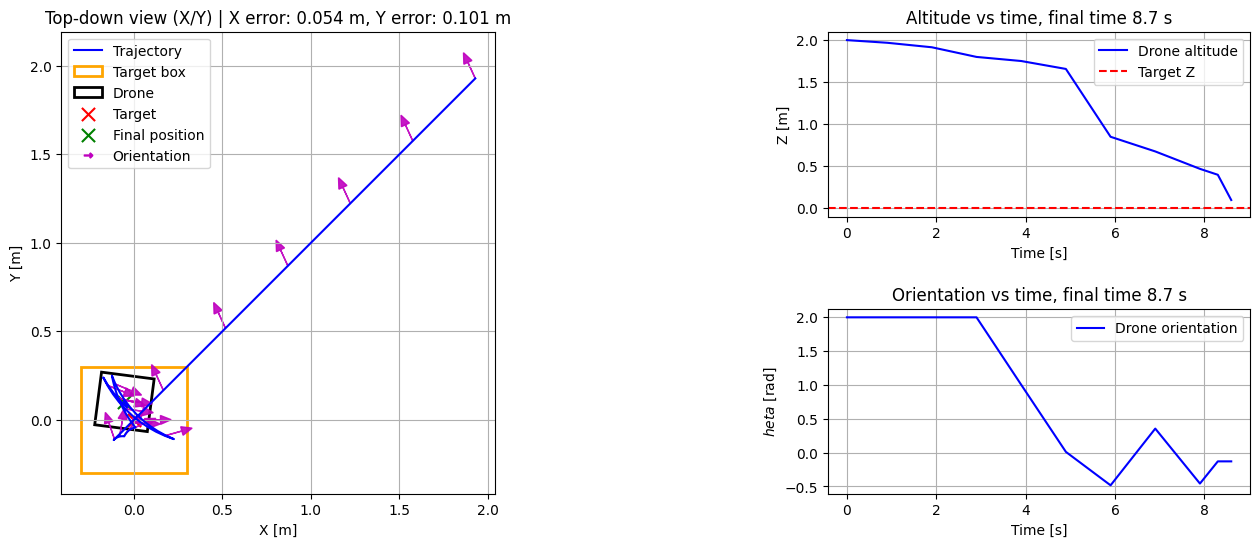

In [2]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[2.0,2.0,2.0, 2.0], Ki=[0.1,0.1,0.0,0.2], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_2_steps =True)

states, target = run_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0, 2.0], verbose=True)

In [3]:
import numpy as np
R= np.array([[-0.41614681 , 0.90929741 , 0.        ],
 [-0.90929741, -0.41614681 , 0.        ],
 [ 0.       ,   0.      ,    1.        ]])

In [4]:
R

array([[-0.41614681,  0.90929741,  0.        ],
       [-0.90929741, -0.41614681,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

In [5]:
R.T@R

array([[0.99999995, 0.        , 0.        ],
       [0.        , 0.99999995, 0.        ],
       [0.        , 0.        , 1.        ]])

In [6]:
error = np.array([-2., -2., -2., -2.])

In [7]:
error

array([-2., -2., -2., -2.])

In [8]:
theta = 2.0

In [9]:
print(error)
c, s = np.cos(theta), np.sin(theta)
R = np.array([
  [c, s, 0],
  [-s, c, 0],
  [0, 0, 1]
])  # world-to-body rotation (transpose of body-to-world)

print(R)

body_output = np.zeros_like(error)
body_output[:3] = R @ error[:3]   # rotate linear part
body_output[3] = error[3]         # yaw rate unchanged

print(body_output )

[-2. -2. -2. -2.]
[[-0.41614684  0.90929743  0.        ]
 [-0.90929743 -0.41614684  0.        ]
 [ 0.          0.          1.        ]]
[-0.98630118  2.65088853 -2.         -2.        ]


In [10]:
body_output

array([-0.98630118,  2.65088853, -2.        , -2.        ])